# Gradient

Gradient of scalar field $f(x,y,z)$ at a given point $(x,y,z)$ it is defined as a vector indicating the direction of the greatest change of the scalar field, with a magnitude proportional to that change. The general formula for calculating the gradient in Cartesian coordinates is defined as:

\begin{equation}
\nabla f =  \frac{\partial f}{\partial x} \mathbf{i} + \frac{\partial f}{\partial y} \mathbf{j}  +  \frac{\partial f}{\partial z} \mathbf{k}
\end{equation}

## Gradient in Cylindrical Coordinates

The gradient of a scalar function $(f(r, \varphi, z))$ in cylindrical coordinates is given by:

\begin{equation}
\nabla f = \frac{\partial f}{\partial r} \, \boldsymbol{r} 
  + \frac{1}{r} \frac{\partial f}{\partial \varphi} \, \boldsymbol{\varphi} 
  + \frac{\partial f}{\partial z} \, \boldsymbol{z}
\end{equation}

**Explanation:**  

- $\mathbf{r}$, $\boldsymbol{\varphi}$, and $\mathbf{z}$ are the unit vectors in the **radial**, **angular**, and **vertical** directions, respectively.  
- $\frac{\partial f}{\partial r}$ gives the rate of change of $f$ in the **radial** direction.  
- $\frac{1}{r} \frac{\partial f}{\partial \varphi}$ gives the rate of change of $f$ in the **angular** direction; the factor $1/r$ accounts for the circular arc length dependence on the radius.  
- $\frac{\partial f}{\partial z}$ gives the rate of change of $f$ in the **vertical** direction.  

The gradient vector points in the direction of the **greatest increase** of the scalar function $f$, and its magnitude represents the rate of that increase.





## Gradient in Spherical Coordinates

The gradient of a scalar function $f(r, \theta, \varphi)$ in spherical coordinates is given by:

\begin{equation}
\nabla f = \frac{\partial f}{\partial r} \, \mathbf{r} 
  + \frac{1}{r} \frac{\partial f}{\partial \theta} \, \boldsymbol{\theta} 
  + \frac{1}{r \sin \theta} \frac{\partial f}{\partial \varphi} \, \boldsymbol{\varphi}
\end{equation}

**Explanation:**  

- $\mathbf{r}$, $\boldsymbol{\theta}$, and $\boldsymbol{\varphi}$ are the unit vectors in the **radial**, **polar (colatitude)**, and **azimuthal** directions, respectively.  
- $\frac{\partial f}{\partial r}$ gives the rate of change of $f$ in the **radial** direction.  
- $\frac{1}{r} \frac{\partial f}{\partial \theta}$ gives the rate of change of $f$ along the **polar** direction; the factor $1/r$ accounts for the arc length along a circle of radius $r$.  
- $\frac{1}{r \sin \theta} \frac{\partial f}{\partial \varphi}$ gives the rate of change of $f$ along the **azimuthal** direction; the factor $1/(r \sin \theta)$ accounts for the arc length along a circle of radius $r \sin \theta$.  

The gradient vector points in the direction of the **greatest increase** of the scalar function $f$, and its magnitude represents the rate of that increase.




## Properties of the Gradient

If $\mathbf{F}, \mathbf{G}$ are vector fields, $f, g$ are scalar fields, and $a, b$ are real numbers, then the gradient operator satisfies the following identities:

- **Linearity with respect to real numbers**

\begin{equation*}
\nabla\left(a f + b g\right) = a \nabla f + b \nabla g
\end{equation*}

This means that the gradient of a linear combination of scalar fields is the same linear combination of their gradients.

- **Leibniz rule (product rule)**

\begin{equation*}
\nabla\left(f g\right) = \left(\nabla f\right) g + f \nabla g
\end{equation*}

This shows that the gradient of a product of two scalar fields follows the familiar product rule from calculus.

- **Gradient of the scalar (dot) product of vectors**

\begin{equation*}
\nabla\left(\mathbf{F} \cdot \mathbf{G}\right) = \nabla \mathbf{F} \cdot \mathbf{G} + \nabla \mathbf{G} \cdot \mathbf{F}
\end{equation*}

Here, $\nabla \mathbf{F}$ is understood as a **matrix** (Jacobian of $\mathbf{F}$), and the result is interpreted as a **column vector**. (**TODO:** provide a proof or derivation)

**Explanation:**  

- Linearity: scaling and adding scalar fields before taking the gradient is equivalent to scaling and adding their gradients afterward.  
- Leibniz rule: the gradient of a product of scalar fields splits into the sum of each field multiplied by the gradient of the other.  
- Gradient of a dot product: for vector fields, the gradient of the scalar product involves the Jacobian matrices of the vectors, producing a column vector representing the directional rate of change.


## Symbolic Calculation

Using the *sympy* library, we can determine the gradient of a scalar function

\begin{equation*}
f(x, y) = (x^2 + y) \, \sin(y)
\end{equation*}

and its value at the point $(x, y) = (2, 4)$.

<!-- MEDSKIP -->

In [1]:
%reset -sf 
from utils.utils import *
from sympy import *
from sympy.vector import CoordSys3D, gradient

r = CoordSys3D('r')
f = (r.x**2 + r.y) * sin(r.y)       # Skalar func f(x,y) 
G = gradient(f)                     # Calculation of the Gradient

ltxprint(r'\nabla f(x,y)', G)

ModuleNotFoundError: No module named 'sympy'

Calculation of the gradient vector components at a point $(x,y)=(2,4)$

In [2]:
gxy = G.subs([(r.x, 2), (r.y, 4)])
print('Grad f(2,4) = {0} {1}'.format(gxy, gxy.evalf(3)))

NameError: name 'G' is not defined

## Numerical Calculation

In *numpy*, the function `gradient()` can be used to compute the gradient of an n-dimensional scalar function. 

The function returns a vector field, which can be visualized in 2D using the `quiver()` function; the arrows point in the direction of increasing values.

<!-- MEDSKIP -->


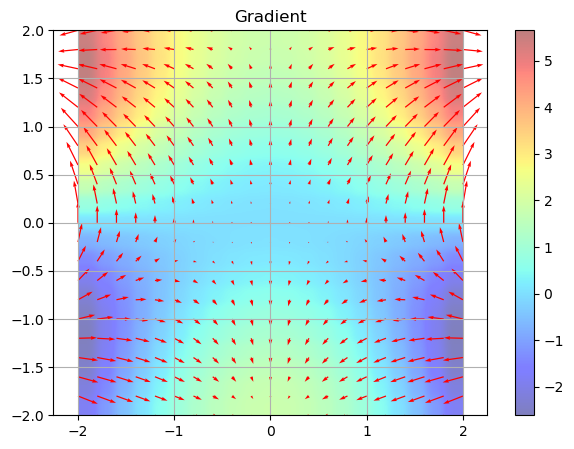

In [3]:
%reset -sf 
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np                    

dx = np.arange(-2, 2.2, .2)
dy = np.arange(-2, 2.2, .2)
x,y = np.meshgrid(dx, dy)   

fn = (x**2 + y) * np.sin(y)
gy, gx = np.gradient(fn)

fig = plt.figure(figsize=(7,5)) 
ax = fig.add_subplot(111)
ax.quiver(x, y, gx, gy, color='r')
img = ax.imshow(fn, extent=[-2, 2, -2, 2], 
                origin='lower', interpolation='kaiser', 
                clip_on=True, alpha=0.5, cmap='jet') 
fig.colorbar(img)
plt.axis('equal')
plt.title('Gradient')
plt.grid()
plt.show()